### Forecasting Hays County Housing-Market Speed
-----------------------------------------  

Title: Project 1 / Milestone 2  
Author: Teresa Ferrill    
Date:  September 27, 2026  
Modified By: Teresa Ferrill  
Description: This project examines whether past housing-market conditions and mortgage rates can help forecast Hays County’s median days on market for the following month. The findings could be incorporated into a customer relationship management dashboard to help real estate professionals interpret market conditions and advise their clients.  
 
-----------------------------------------

Contents:  
 1.  Setup and Data Loading
 2.  Data-Quality Review
 3.  Define Quality Status
 4.  Target and Feature Creation
 5.  Create Seasonal Features and Baselines
 6.  Exploratory Data Analysis
 7.  Model Preparation and Chronological Validation
 8.  Baseline Forecasts
 9.  Regression Models
 10. Model Comparison
 11. Ridge Regression Coefficients
 12. Quality-Flag Sensitivity Analysis
 13. Prediction Errors
 14. September 2026 Forecast
 15. Conclusion
 16. Assumptions and Limitations
 17. Challenges
 18. Ethical Assessment
 19. Recommendations
 20. Implementation Plan
 21. Future Uses and Additional Applications
 22. GitHub and Reproducibility

-----------------------------------------

### Business Problem and Research Questions

Real estate professionals need timely market information when advising buyers and sellers about how long properties may remain available. Historical housing reports describe previous conditions but do not directly estimate the following month's market speed. This project evaluates whether recent housing-market conditions, mortgage rates, and seasonal patterns can support a useful one-month-ahead forecast for Hays County, Texas.  

The primary research question is:  

**To what extent can housing inventory, listing prices, mortgage rates, and seasonal trends predict Hays County's median days on market one month in 
advance?**  

Supporting questions include:  

1. Which variables have the strongest relationship with the following month's median days on market?  
2. Do the regression models outperform previous-month and prior-year seasonal baselines?  
3. How can the forecast be translated into useful guidance for real estate professionals?  

-----------------------------------------   

### 1. Setup and Data Loading

This section imports the required libraries, loads the Realtor.com and Freddie Mac source datasets, and merges them using the monthly date identifier. The resulting observations are prepared for chronological time-series analysis.

In [1]:
# Import Statements
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

### Prepare Freddie Mac Mortgage-Rate Data

The original Freddie Mac dataset contains weekly mortgage-rate observations.  

* The first two rows contain multi-level headings, so they are skipped when the file is loaded.  
* The `Week` and `FRM` fields are retained and renamed to identify the observation date and 30-year fixed mortgage rate. 
* Weekly rates are grouped by calendar month and averaged so that they can be joined with the monthly Realtor.com housing data.
* The analysis is limited to July 2016 through August 2026 to match the housing dataset.

In [2]:
# Load the original weekly data
freddie_weekly = pd.read_csv(
    "../data/FreddieMac_1971-2026_historicalweeklydata.csv",
    skiprows=2,
    usecols=["Week", "FRM"],
    encoding="utf-8-sig"
)

freddie_weekly.head()

,Week,FRM
0,4/2/1971,7.33
1,4/9/1971,7.31
2,4/16/1971,7.31
3,4/23/1971,7.31
4,4/30/1971,7.29


In [3]:
# Rename and convert the fields
freddie_weekly = freddie_weekly.rename(
    columns={
        "Week": "week_date",
        "FRM": "mortgage_rate_30yr_pct"
    }
)

freddie_weekly["week_date"] = pd.to_datetime(
    freddie_weekly["week_date"],
    errors="coerce"
)

freddie_weekly["mortgage_rate_30yr_pct"] = pd.to_numeric(
    freddie_weekly["mortgage_rate_30yr_pct"],
    errors="coerce"
)

In [4]:
# Check for invalid records
print("Original weekly rows:", len(freddie_weekly))
print("Invalid dates:", freddie_weekly["week_date"].isna().sum())
print(
    "Missing mortgage rates:",
    freddie_weekly["mortgage_rate_30yr_pct"].isna().sum()
)

Original weekly rows: 2893
Invalid dates: 0
Missing mortgage rates: 0


In [5]:
# Remove an invalid record only if the checks identify one:
freddie_weekly = freddie_weekly.dropna(
    subset=["week_date", "mortgage_rate_30yr_pct"]
).copy()

In [6]:
# Create the monthly identifier
freddie_weekly["month_date_yyyymm"] = (
    freddie_weekly["week_date"]
    .dt.strftime("%Y%m")
    .astype(int)
)

In [7]:
# Calculate monthly averages
freddie_monthly = (
    freddie_weekly
    .groupby("month_date_yyyymm", as_index=False)
    .agg(
        mortgage_rate_30yr_pct=(
            "mortgage_rate_30yr_pct",
            "mean"
        ),
        weekly_observations=(
            "mortgage_rate_30yr_pct",
            "count"
        )
    )
)

In [8]:
# Limit the results to the housing-data period
freddie_monthly = freddie_monthly[
    freddie_monthly["month_date_yyyymm"].between(
        201607,
        202608
    )
].copy()

freddie_monthly["mortgage_rate_30yr_pct"] = (
    freddie_monthly["mortgage_rate_30yr_pct"].round(4)
)

In [9]:
# Verify the prepared data
expected_months = pd.period_range(
    start="2016-07",
    end="2026-08",
    freq="M"
)

actual_months = pd.PeriodIndex(
    pd.to_datetime(
        freddie_monthly["month_date_yyyymm"].astype(str),
        format="%Y%m"
    ),
    freq="M"
)

missing_months = expected_months.difference(actual_months)

print("Monthly observations:", len(freddie_monthly))
print(
    "Duplicate months:",
    freddie_monthly["month_date_yyyymm"].duplicated().sum()
)
print(
    "Missing mortgage rates:",
    freddie_monthly["mortgage_rate_30yr_pct"].isna().sum()
)
print("Missing months:", len(missing_months))

freddie_monthly.head()

Monthly observations: 122
Duplicate months: 0
Missing mortgage rates: 0
Missing months: 0


,month_date_yyyymm,mortgage_rate_30yr_pct,weekly_observations
543,201607,3.440,4
544,201608,3.435,4
545,201609,3.460,5
546,201610,3.470,4
547,201611,3.770,4


### Prepare Realtor.com Housing Data

The original Realtor.com dataset contains monthly housing-market measurements for counties throughout the United States. 

* County FIPS codes were loaded as text to preserve any leading zeros.
* The dataset was filtered to county FIPS 48209, representing Hays County, Texas.
* Only the fields needed for the analysis were retained.
* The filtered data were sorted chronologically and checked for duplicate months, missing months, missing values, and invalid numeric values.

In [10]:
# Load only the required fields
housing_columns = [
    "month_date_yyyymm",
    "county_fips",
    "county_name",
    "median_listing_price",
    "active_listing_count",
    "median_days_on_market",
    "new_listing_count",
    "price_increased_count",
    "price_reduced_count",
    "pending_listing_count",
    "pending_ratio",
    "quality_flag"
]

realtor_county = pd.read_csv(
    "../data/RDC_Inventory_Core_Metrics_County_History.csv",
    usecols=housing_columns,
    dtype={"county_fips": "string"}
)

print("Original county-month records:", len(realtor_county))
print("Selected fields:", len(realtor_county.columns))

realtor_county.head()

Original county-month records: 378625
Selected fields: 12


,month_date_yyyymm,county_fips,county_name,median_listing_price,active_listing_count,median_days_on_market,new_listing_count,price_increased_count,price_reduced_count,pending_listing_count,pending_ratio,quality_flag
0,202608,39081,"jefferson, oh",172000.0,139,52.0,60,0,64,83.0,0.5971,0.0
1,202608,01049,"dekalb, al",299900.0,251,76.0,76,0,68,55.0,0.2191,0.0
2,202608,24039,"somerset, md",250000.0,124,84.0,32,0,48,40.0,0.3226,0.0
3,202608,26137,"otsego, mi",329500.0,156,52.0,64,0,68,59.0,0.3782,0.0
4,202608,53025,"grant, wa",415000.0,470,81.0,112,4,120,121.0,0.2574,0.0


In [11]:
# Standardize the FIPS code
realtor_county["county_fips"] = (
    realtor_county["county_fips"]
    .str.strip()
    .str.zfill(5)
)

In [12]:
# Filter to Hays County 
housing = realtor_county[
    realtor_county["county_fips"].eq("48209")
].copy()

print("Hays County observations:", len(housing))
print(housing["county_name"].value_counts(dropna=False))

Hays County observations: 122
county_name
hays, tx    122
Name: count, dtype: int64


In [13]:
# Confirm the county identity
assert len(housing) > 0, "No records found for county FIPS 48209."

assert housing["county_name"].str.lower().eq(
    "hays, tx"
).all(), "The selected records do not all represent Hays County, Texas."

In [14]:
# Convert the fields to numeric values
numeric_columns = [
    "month_date_yyyymm",
    "median_listing_price",
    "active_listing_count",
    "median_days_on_market",
    "new_listing_count",
    "price_increased_count",
    "price_reduced_count",
    "pending_listing_count",
    "pending_ratio",
    "quality_flag"
]

for column in numeric_columns:
    housing[column] = pd.to_numeric(
        housing[column],
        errors="coerce"
    )

In [15]:
# Sort the data chronologically
housing = (
    housing
    .sort_values("month_date_yyyymm")
    .reset_index(drop=True)
)

housing[
    [
        "month_date_yyyymm",
        "county_fips",
        "county_name"
    ]
].head()

,month_date_yyyymm,county_fips,county_name
0,201607,48209,"hays, tx"
1,201608,48209,"hays, tx"
2,201609,48209,"hays, tx"
3,201610,48209,"hays, tx"
4,201611,48209,"hays, tx"


In [16]:
# Check the date range and duplicates
print("Starting month:", housing["month_date_yyyymm"].min())
print("Ending month:", housing["month_date_yyyymm"].max())
print(
    "Duplicate months:",
    housing["month_date_yyyymm"].duplicated().sum()
)

Starting month: 201607
Ending month: 202608
Duplicate months: 0


In [17]:
# Check for missing months
housing_dates = pd.to_datetime(
    housing["month_date_yyyymm"].astype(str),
    format="%Y%m",
    errors="coerce"
)

expected_housing_months = pd.date_range(
    start="2016-07-01",
    end="2026-08-01",
    freq="MS"
)

missing_housing_months = expected_housing_months.difference(
    housing_dates
)

print("Expected months:", len(expected_housing_months))
print("Actual months:", len(housing))
print("Missing months:", len(missing_housing_months))

if len(missing_housing_months) > 0:
    print(missing_housing_months)

Expected months: 122
Actual months: 122
Missing months: 0


In [18]:
# Review missing values
print("Missing values by field:")
print(housing.isna().sum())

Missing values by field:
month_date_yyyymm         0
county_fips               0
county_name               0
median_listing_price      0
active_listing_count      0
median_days_on_market     0
new_listing_count         0
price_increased_count     0
price_reduced_count       0
pending_listing_count     0
pending_ratio             0
quality_flag             12
dtype: int64


In [19]:
# Review the quality-flag values
print(
    housing["quality_flag"].value_counts(
        dropna=False
    )
)

quality_flag
0.0    70
1.0    40
NaN    12
Name: count, dtype: int64


In [20]:
# Check for invalid negative values
nonnegative_columns = [
    "median_listing_price",
    "active_listing_count",
    "median_days_on_market",
    "new_listing_count",
    "price_increased_count",
    "price_reduced_count",
    "pending_listing_count",
    "pending_ratio"
]

negative_counts = (
    housing[nonnegative_columns]
    .lt(0)
    .sum()
)

print("Negative values by field:")
print(negative_counts)

Negative values by field:
median_listing_price     0
active_listing_count     0
median_days_on_market    0
new_listing_count        0
price_increased_count    0
price_reduced_count      0
pending_listing_count    0
pending_ratio            0
dtype: int64


In [21]:
# Verify allowed quality-flag values
unexpected_quality_flags = housing.loc[
    housing["quality_flag"].notna()
    & ~housing["quality_flag"].isin([0, 1]),
    "quality_flag"
]

print(
    "Unexpected quality-flag values:",
    len(unexpected_quality_flags)
)

Unexpected quality-flag values: 0


In [22]:
# Save the prepared file
mortgage = freddie_monthly[
    [
        "month_date_yyyymm",
        "mortgage_rate_30yr_pct"
    ]
].copy()

mortgage.to_csv(
    "../data/freddie_mac_monthly.csv",
    index=False
)

mortgage.tail()

,month_date_yyyymm,mortgage_rate_30yr_pct
660,202604,6.3320
661,202605,6.4425
662,202606,6.4900
663,202607,6.5420
664,202608,6.6675


In [23]:
# Remove county-identification fields from the modeling file
housing = housing[
    [
        "month_date_yyyymm",
        "median_listing_price",
        "active_listing_count",
        "median_days_on_market",
        "new_listing_count",
        "price_increased_count",
        "price_reduced_count",
        "pending_listing_count",
        "pending_ratio",
        "quality_flag"
    ]
].copy()

In [24]:
# Save the prepared housing data
housing.to_csv(
    "../data/realtor_hays_county.csv",
    index=False
)

print("Saved housing observations:", len(housing))
housing.head()

Saved housing observations: 122


,month_date_yyyymm,median_listing_price,active_listing_count,median_days_on_market,new_listing_count,price_increased_count,price_reduced_count,pending_listing_count,pending_ratio,quality_flag
0,201607,362450.0,786,56.0,338,44,298,371.0,0.4714,NaN
1,201608,336750.0,795,58.0,326,34,308,360.0,0.4525,NaN
2,201609,341468.0,783,62.0,246,56,278,315.0,0.4026,NaN
3,201610,334950.0,759,65.0,292,60,284,274.0,0.3610,NaN
4,201611,331950.0,729,71.0,242,44,232,248.0,0.3395,NaN


### Merge the Prepared Data Sources

The prepared Realtor.com and Freddie Mac datasets each contain one observation per month from July 2016 through August 2026. The datasets are joined using `month_date_yyyymm`.  

A left join retains all Hays County housing observations, while one-to-one validation confirms that neither source contains duplicate monthly identifiers.  

The merged dataset is saved for the exploratory analysis and forecasting models.

In [25]:
# Merge prepared data sources
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

housing["month_date_yyyymm"] = (
    housing["month_date_yyyymm"].astype(int)
)

mortgage["month_date_yyyymm"] = (
    mortgage["month_date_yyyymm"].astype(int)
)

modeling_data = housing.merge(
    mortgage,
    on="month_date_yyyymm",
    how="left",
    validate="one_to_one"
)

print("Merged dataset shape:", modeling_data.shape)
print(
    "Missing mortgage rates after merge:",
    modeling_data["mortgage_rate_30yr_pct"].isna().sum()
)

modeling_data.to_csv(
    "../data/hays_county_modeling_data.csv",
    index=False
)

Merged dataset shape: (122, 11)
Missing mortgage rates after merge: 0


In [26]:
# Final merge validation
assert len(modeling_data) == len(housing), (
    "The merge changed the number of housing observations."
)

assert modeling_data["month_date_yyyymm"].is_unique, (
    "The merged dataset contains duplicate months."
)

assert modeling_data["mortgage_rate_30yr_pct"].notna().all(), (
    "One or more housing months did not match a mortgage rate."
)

### 2. Data-Quality Review

The merged dataset is checked for chronological coverage, duplicate months, missing months, missing mortgage rates, and quality-flag values before creating the prediction target.  

In [27]:
# Convert the YYYYMM identifier into a date for time-series analysis
modeling_data["date"] = pd.to_datetime(
    modeling_data["month_date_yyyymm"].astype(str),
    format="%Y%m"
)

# Sort the observations chronologically
modeling_data = (
    modeling_data
    .sort_values("date")
    .reset_index(drop=True)
)

# Create the complete sequence of expected months
expected_months = pd.date_range(
    start=modeling_data["date"].min(),
    end=modeling_data["date"].max(),
    freq="MS"
)

missing_months = expected_months.difference(modeling_data["date"])

print("Dataset shape:", modeling_data.shape)
print("Starting month:", modeling_data["date"].min())
print("Ending month:", modeling_data["date"].max())
print("Duplicate months:", modeling_data["month_date_yyyymm"].duplicated().sum())
print("Missing months:", len(missing_months))
print(
    "Missing mortgage rates:",
    modeling_data["mortgage_rate_30yr_pct"].isna().sum()
)

print("\nMissing values by field:")
print(modeling_data.isna().sum())

print("\nQuality-flag values:")
print(modeling_data["quality_flag"].value_counts(dropna=False))

Dataset shape: (122, 12)
Starting month: 2016-07-01 00:00:00
Ending month: 2026-08-01 00:00:00
Duplicate months: 0
Missing months: 0
Missing mortgage rates: 0

Missing values by field:
month_date_yyyymm          0
median_listing_price       0
active_listing_count       0
median_days_on_market      0
new_listing_count          0
price_increased_count      0
price_reduced_count        0
pending_listing_count      0
pending_ratio              0
quality_flag              12
mortgage_rate_30yr_pct     0
date                       0
dtype: int64

Quality-flag values:
quality_flag
0.0    70
1.0    40
NaN    12
Name: count, dtype: int64


### Data Dictionary

| Field | Description | Analytical role |
|---|---|---|
| `month_date_yyyymm` | Monthly observation identifier in YYYYMM format | Join and time identifier |
| `median_listing_price` | Median asking price of active listings | Predictor |
| `active_listing_count` | Number of active property listings | Predictor |
| `median_days_on_market` | Median time listings remained on the market | Predictor |
| `new_listing_count` | Number of newly listed properties | Predictor |
| `price_increased_count` | Listings with an increased asking price | Descriptive field; not used as a model predictor |
| `price_reduced_count` | Listings with a reduced asking price | Predictor |
| `pending_listing_count` | Listings with pending sales | Predictor |
| `pending_ratio` | Pending listings relative to active listings | Predictor |
| `quality_flag` | Realtor.com indicator of an unusual year-over-year change | Quality assessment |
| `mortgage_rate_30yr_pct` | Monthly average 30-year fixed mortgage rate | Predictor |
| `median_days_on_market_next_month` | Following month's median days on market | Target |

### 3. Define Quality Status  

The original quality flag contains 12 blank values because the first year of observations could not be evaluated using the year-over-year quality rule. A descriptive field distinguishes flagged, unflagged, and unevaluated records without changing the original data.  

In [28]:
modeling_data["quality_status"] = np.select(
    [
        modeling_data["quality_flag"].eq(1),
        modeling_data["quality_flag"].eq(0)
    ],
    [
        "Flagged",
        "Not flagged"
    ],
    default="Not evaluated"
)

print(modeling_data["quality_status"].value_counts())

quality_status
Not flagged      70
Flagged          40
Not evaluated    12
Name: count, dtype: int64


### 4. Target and Feature Creation  

The project predicts median days on market one month in advance. Each row contains predictor values from the current month and the median days on market from the following month as the target.  

In [29]:
# Identify the month being predicted
modeling_data["target_date"] = modeling_data["date"].shift(-1)

# Move the following month's outcome onto the current month's row
modeling_data["median_days_on_market_next_month"] = (
    modeling_data["median_days_on_market"].shift(-1)
)

# Verify the alignment
modeling_data[
    [
        "date",
        "target_date",
        "median_days_on_market",
        "median_days_on_market_next_month"
    ]
].head()

,date,target_date,median_days_on_market,median_days_on_market_next_month
0,2016-07-01,2016-08-01,56.0,58.0
1,2016-08-01,2016-09-01,58.0,62.0
2,2016-09-01,2016-10-01,62.0,65.0
3,2016-10-01,2016-11-01,65.0,71.0
4,2016-11-01,2016-12-01,71.0,78.0


### 5. Create Seasonal Features and Baselines

In [30]:
# Extract the calendar month
modeling_data["month_number"] = modeling_data["date"].dt.month

# Represent annual seasonality without treating December and January
# as being far apart
modeling_data["month_sin"] = np.sin(
    2 * np.pi * modeling_data["month_number"] / 12
)

modeling_data["month_cos"] = np.cos(
    2 * np.pi * modeling_data["month_number"] / 12
)

# Baseline 1:
# Predict that next month will equal the current month
modeling_data["previous_month_baseline"] = (
    modeling_data["median_days_on_market"]
)

# Baseline 2:
# Predict the target using the same calendar month from the prior year
modeling_data["seasonal_baseline"] = (
    modeling_data["median_days_on_market"].shift(11)
)

# Remove the row without a target
model_data = modeling_data.dropna(
    subset=["median_days_on_market_next_month"]
).copy()

print("Merged observations:", len(modeling_data))
print("Usable modeling observations:", len(model_data))

Merged observations: 122
Usable modeling observations: 121


In [31]:
# Establish Target Quality Flag
modeling_data["target_quality_flag"] = (
    modeling_data["quality_flag"].shift(-1)
)

model_data = modeling_data.dropna(
    subset=["median_days_on_market_next_month"]
).copy()

### 6. Exploratory Data Analysis

Exploratory analysis examines changes in market speed and mortgage rates over time, seasonal differences, relationships among the predictors, and possible changes surrounding the COVID-19 pandemic. These results will also provide illustrations for the final white paper.

In [32]:
# Descriptive analytics

analysis_columns = [
    "median_days_on_market",
    "median_listing_price",
    "active_listing_count",
    "new_listing_count",
    "pending_listing_count",
    "price_reduced_count",
    "pending_ratio",
    "mortgage_rate_30yr_pct"
]

modeling_data[analysis_columns].describe().round(2)

,median_days_on_market,median_listing_price,active_listing_count,new_listing_count,pending_listing_count,price_reduced_count,pending_ratio,mortgage_rate_30yr_pct
count,122.00,122.00,122.00,122.00,122.00,122.00,122.00,122.00
mean,57.12,411780.46,936.06,401.62,435.98,375.54,0.69,4.92
std,17.25,81162.41,375.18,108.08,188.58,216.00,0.91,1.50
min,16.00,314600.00,165.00,164.00,133.00,16.00,0.12,2.68
25%,47.00,336542.25,743.50,333.00,279.75,202.00,0.32,3.64
50%,56.50,412920.00,935.00,396.00,386.50,368.00,0.40,4.50
75%,68.00,472305.75,1144.50,468.50,559.50,553.50,0.49,6.48
max,94.00,630331.00,1675.00,724.00,941.00,874.00,5.02,7.62


#### 6.1 Housing-Market Speed Over Time  

The monthly trend illustrates changes in Hays County’s median days on market from July 2016 through August 2026. The recurring increases and decreases also provide initial evidence of seasonal variation.

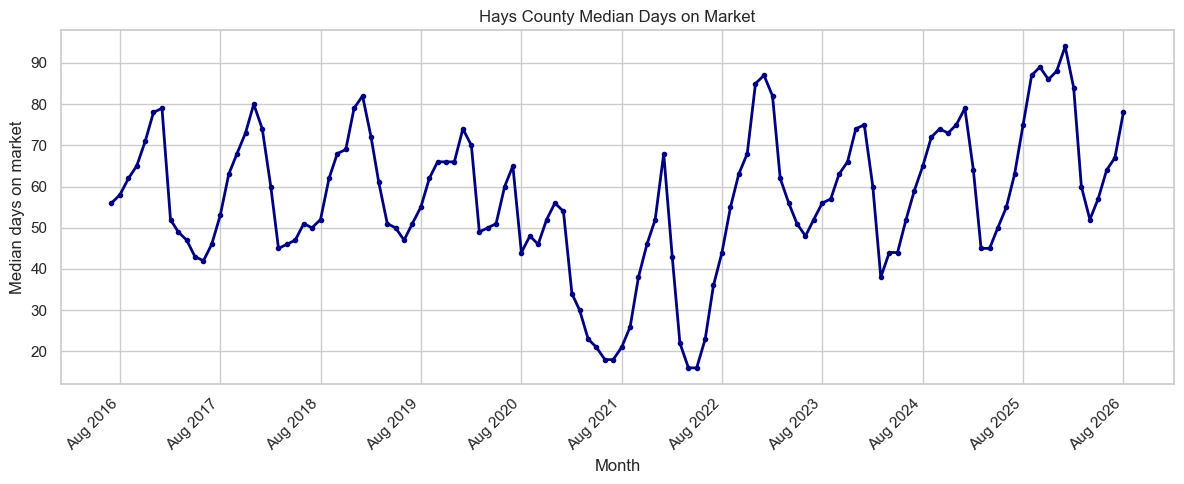

In [33]:
# Display August once each year
# Line Chart displaying Hays County Median Days on Market
plt.figure(figsize=(12, 5))

plt.plot(
    modeling_data["date"],
    modeling_data["median_days_on_market"],
    color="navy",
    linewidth=2,
    marker="o",
    markersize=3
)

plt.title("Hays County Median Days on Market")
plt.xlabel("Month")
plt.ylabel("Median days on market")

plt.gca().xaxis.set_major_locator(
    mdates.MonthLocator(bymonth=8, interval=1)
)
plt.gca().xaxis.set_major_formatter(
    mdates.DateFormatter("%b %Y")
)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

#### 6.2 Mortgage Rates and Median Days on Market   

The following illustration compares changes in mortgage rates with changes in median days on market. The variables are presented in separate panels because they use different units and scales.

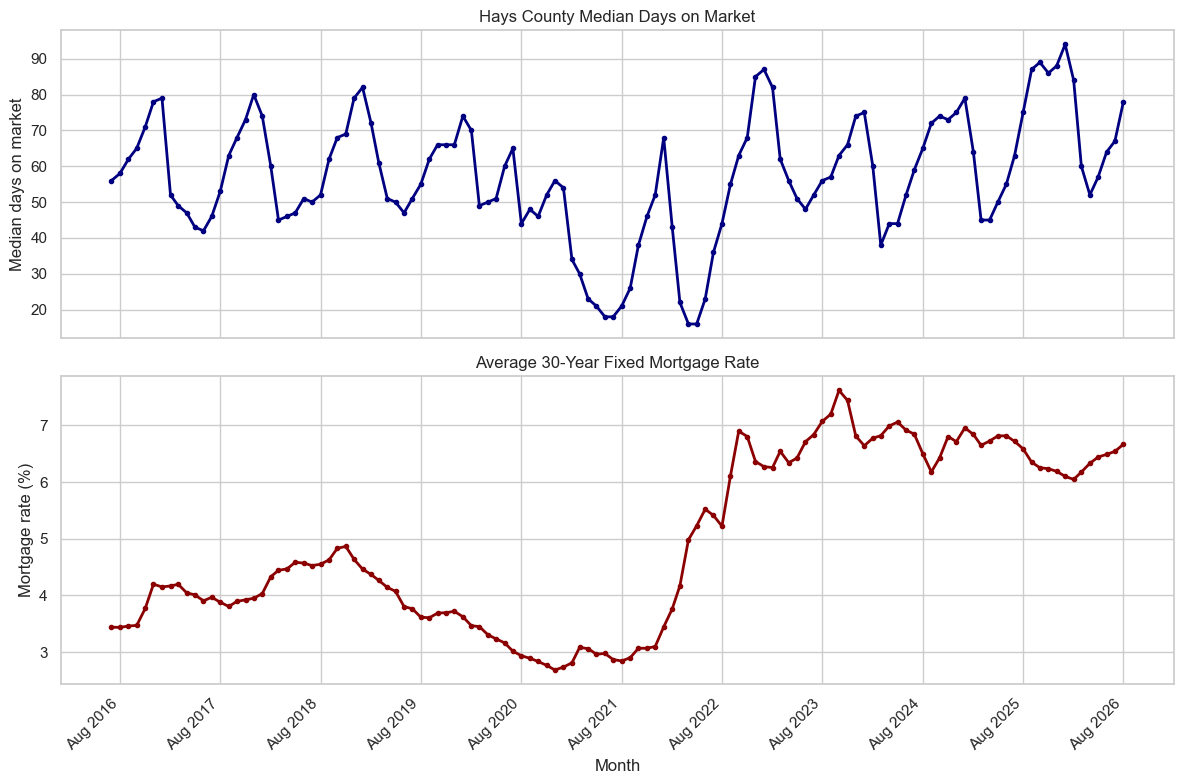

In [34]:
fig, axes = plt.subplots(
    2,
    1,
    figsize=(12, 8),
    sharex=True
)

axes[0].plot(
    modeling_data["date"],
    modeling_data["median_days_on_market"],
    color="navy",
    linewidth=2,
    marker="o",
    markersize=3
)

axes[0].set_title("Hays County Median Days on Market")
axes[0].set_ylabel("Median days on market")

axes[1].plot(
    modeling_data["date"],
    modeling_data["mortgage_rate_30yr_pct"],
    color="darkred",
    linewidth=2,
    marker="o",
    markersize=3
)

axes[1].set_title("Average 30-Year Fixed Mortgage Rate")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Mortgage rate (%)")

axes[1].xaxis.set_major_locator(
    mdates.MonthLocator(bymonth=8, interval=1)
)

axes[1].xaxis.set_major_formatter(
    mdates.DateFormatter("%b %Y")
)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

#### 6.3 Seasonal Market Patterns

The summary table compares median days on market across calendar months to identify recurring seasonal patterns.

In [35]:
seasonal_summary = (
    modeling_data
    .groupby("month_number")["median_days_on_market"]
    .agg(["mean", "median", "min", "max", "count"])
    .round(2)
    .reset_index()
)

month_names = {
    1: "Jan",
    2: "Feb",
    3: "Mar",
    4: "Apr",
    5: "May",
    6: "Jun",
    7: "Jul",
    8: "Aug",
    9: "Sep",
    10: "Oct",
    11: "Nov",
    12: "Dec"
}

seasonal_summary["month"] = (
    seasonal_summary["month_number"].map(month_names)
)

seasonal_summary

,month_number,mean,median,min,max,count,month
0,1,76.60,77.0,54.0,94.0,10,Jan
1,2,62.10,62.0,34.0,84.0,10,Feb
2,3,46.10,47.0,22.0,62.0,10,Mar
3,4,43.00,46.5,16.0,56.0,10,Apr
4,5,43.00,48.5,16.0,57.0,10,May
5,6,46.00,49.5,18.0,64.0,10,Jun
6,7,51.18,52.0,18.0,67.0,11,Jul
7,8,54.64,55.0,21.0,78.0,11,Aug
8,9,59.40,62.0,26.0,87.0,10,Sep
9,10,64.00,65.5,38.0,89.0,10,Oct


The seasonal chart shows that the median number of days on market generally increases during the fall and winter and declines during the spring.    

January has the highest calendar-month median, while April has the lowest.  

This pattern supports the use of seasonal variables in the forecasting models.

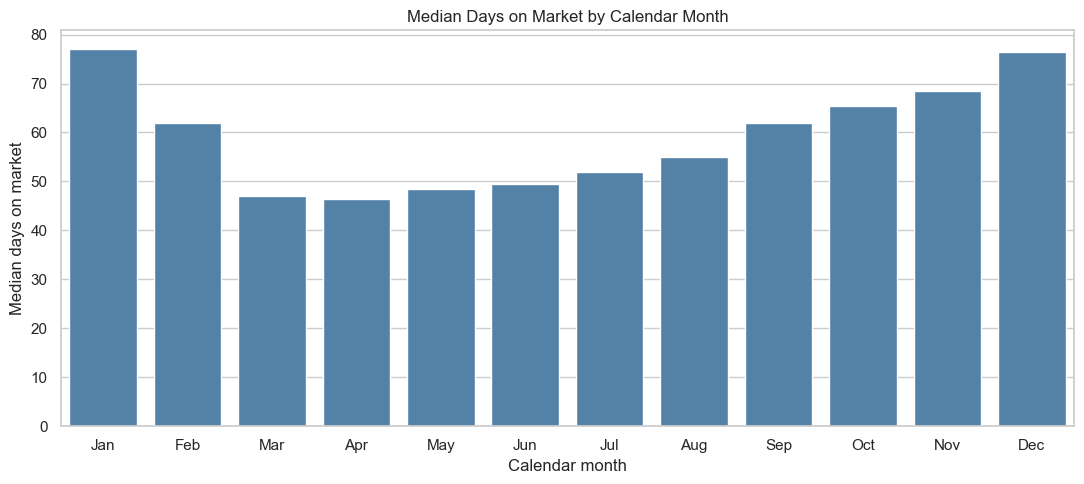

In [36]:
plt.figure(figsize=(11, 5))

sns.barplot(
    data=seasonal_summary,
    x="month",
    y="median",
    color="steelblue"
)

plt.title("Median Days on Market by Calendar Month")
plt.xlabel("Calendar month")
plt.ylabel("Median days on market")
plt.tight_layout()
plt.show()

#### 6.4 Correlation Matrix

A correlation matrix is used to identify relationships between the proposed predictors and the next-month target. It also helps identify predictors that contain similar information.

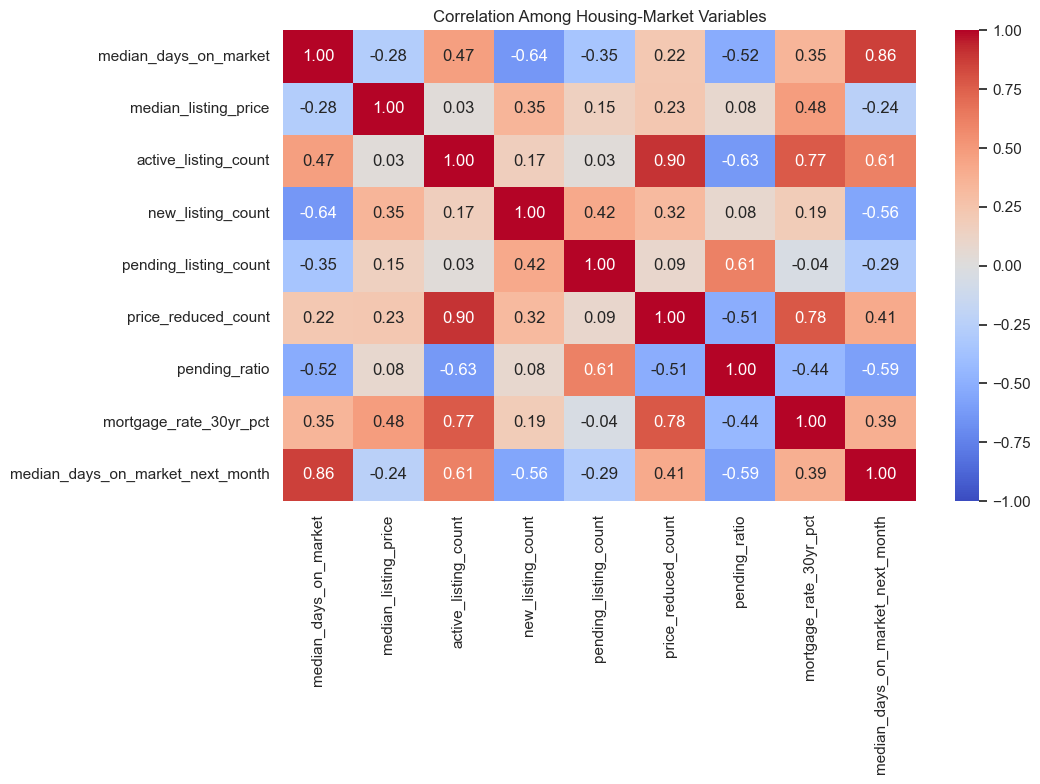

In [37]:
correlation_columns = [
    "median_days_on_market",
    "median_listing_price",
    "active_listing_count",
    "new_listing_count",
    "pending_listing_count",
    "price_reduced_count",
    "pending_ratio",
    "mortgage_rate_30yr_pct",
    "median_days_on_market_next_month"
]

correlation_matrix = (
    model_data[correlation_columns]
    .corr()
    .round(2)
)

plt.figure(figsize=(11, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    fmt=".2f"
)

plt.title("Correlation Among Housing-Market Variables")
plt.tight_layout()
plt.show()

#### 6.5 Market Conditions Before, During, and After the Pandemic  

The data are divided into broad periods to examine whether the pandemic and subsequent market adjustment may represent a structural change in Hays County’s housing market.

In [38]:
modeling_data["market_period"] = np.select(
    [
        modeling_data["date"] < "2020-03-01",
        modeling_data["date"].between(
            "2020-03-01",
            "2021-12-01"
        )
    ],
    [
        "Before March 2020",
        "March 2020–December 2021"
    ],
    default="January 2022 and later"
)

period_summary = (
    modeling_data
    .groupby("market_period", sort=False)
    .agg(
        observations=("date", "count"),
        median_days_on_market=("median_days_on_market", "median"),
        mean_days_on_market=("median_days_on_market", "mean"),
        median_listing_price=("median_listing_price", "median"),
        mean_mortgage_rate=("mortgage_rate_30yr_pct", "mean"),
        median_active_listings=("active_listing_count", "median")
    )
    .round(2)
)

period_summary

,observations,median_days_on_market,mean_days_on_market,median_listing_price,mean_mortgage_rate,median_active_listings
market_period,,,,,,
Before March 2020,44,61.5,60.48,332875.5,4.06,888.0
March 2020–December 2021,22,46.0,41.00,364147.0,2.99,455.0
January 2022 and later,56,62.5,60.82,461782.5,6.36,1181.0


### 7. Model Preparation and Chronological Validation  

The models use current housing-market conditions, mortgage rates, and seasonal variables to predict median days on market for the following month. The data are divided chronologically so that the models are evaluated using later observations that were not available during training.  

Although the final predictor set did not contain missing values, median imputation was retained in each modeling pipeline to support consistent processing if future monthly updates contain incomplete values.

In [39]:
feature_columns = [
    "median_days_on_market",
    "median_listing_price",
    "active_listing_count",
    "new_listing_count",
    "pending_listing_count",
    "price_reduced_count",
    "pending_ratio",
    "mortgage_rate_30yr_pct",
    "month_sin",
    "month_cos"
]

target_column = "median_days_on_market_next_month"

X = model_data[feature_columns]
y = model_data[target_column]

print("Predictor variables:", len(feature_columns))
print("Modeling observations:", len(model_data))
print("Missing predictor values:", X.isna().sum().sum())
print("Missing target values:", y.isna().sum())

Predictor variables: 10
Modeling observations: 121
Missing predictor values: 0
Missing target values: 0


In [40]:
test_months = 24

train_data = model_data.iloc[:-test_months].copy()
test_data = model_data.iloc[-test_months:].copy()

X_train = train_data[feature_columns]
y_train = train_data[target_column]

X_test = test_data[feature_columns]
y_test = test_data[target_column]

print("Training observations:", len(train_data))
print("Test observations:", len(test_data))

print(
    "Training target period:",
    train_data["target_date"].min(),
    "through",
    train_data["target_date"].max()
)

print(
    "Test target period:",
    test_data["target_date"].min(),
    "through",
    test_data["target_date"].max()
)

Training observations: 97
Test observations: 24
Training target period: 2016-08-01 00:00:00 through 2024-08-01 00:00:00
Test target period: 2024-09-01 00:00:00 through 2026-08-01 00:00:00


In [41]:
split_summary = pd.DataFrame({
    "Dataset": ["Training", "Test"],
    "Observations": [len(train_data), len(test_data)],
    "First target month": [
        train_data["target_date"].min(),
        test_data["target_date"].min()
    ],
    "Last target month": [
        train_data["target_date"].max(),
        test_data["target_date"].max()
    ]
})

split_summary

,Dataset,Observations,First target month,Last target month
0,Training,97,2016-08-01,2024-08-01
1,Test,24,2024-09-01,2026-08-01


### 8. Baseline Forecasts  

The regression models are compared with two simple forecasting methods. The previous-month baseline assumes that next month will have the same median days on market as the current month. The seasonal baseline uses the corresponding calendar month from the previous year.

In [42]:
def calculate_metrics(actual, predicted):
    return {
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": np.sqrt(mean_squared_error(actual, predicted)),
        "R2": r2_score(actual, predicted)
    }

In [43]:
baseline_results = []

previous_month_metrics = calculate_metrics(
    y_test,
    test_data["previous_month_baseline"]
)

baseline_results.append({
    "Model": "Previous-month baseline",
    **previous_month_metrics
})

seasonal_metrics = calculate_metrics(
    y_test,
    test_data["seasonal_baseline"]
)

baseline_results.append({
    "Model": "Seasonal baseline",
    **seasonal_metrics
})

baseline_results_df = (
    pd.DataFrame(baseline_results)
    .round(3)
    .sort_values("MAE")
)

baseline_results_df

,Model,MAE,RMSE,R2
0,Previous-month baseline,7.208,9.262,0.573
1,Seasonal baseline,8.708,10.167,0.486


In [44]:
print(
    "Missing previous-month forecasts:",
    test_data["previous_month_baseline"].isna().sum()
)

print(
    "Missing seasonal forecasts:",
    test_data["seasonal_baseline"].isna().sum()
)

Missing previous-month forecasts: 0
Missing seasonal forecasts: 0


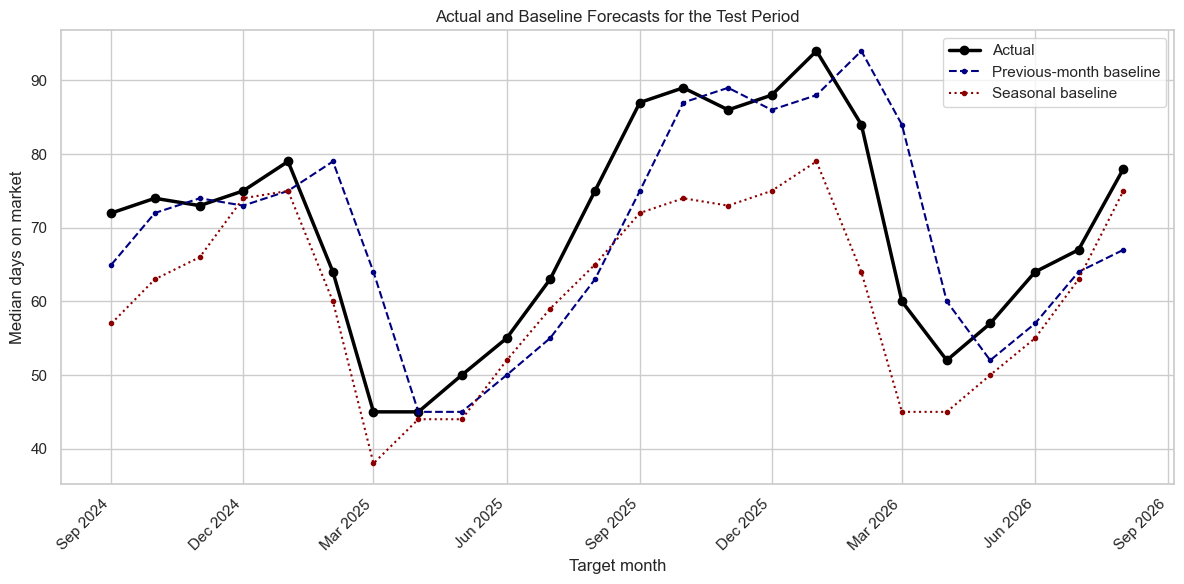

In [45]:
plt.figure(figsize=(12, 6))

plt.plot(
    test_data["target_date"],
    y_test,
    color="black",
    linewidth=2.5,
    marker="o",
    label="Actual"
)

plt.plot(
    test_data["target_date"],
    test_data["previous_month_baseline"],
    color="navy",
    linestyle="--",
    marker="o",
    markersize=3,
    label="Previous-month baseline"
)

plt.plot(
    test_data["target_date"],
    test_data["seasonal_baseline"],
    color="darkred",
    linestyle=":",
    marker="o",
    markersize=3,
    label="Seasonal baseline"
)

plt.title("Actual and Baseline Forecasts for the Test Period")
plt.xlabel("Target month")
plt.ylabel("Median days on market")

plt.gca().xaxis.set_major_locator(
    mdates.MonthLocator(interval=3)
)

plt.gca().xaxis.set_major_formatter(
    mdates.DateFormatter("%b %Y")
)

plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

### 9. Regression Models  

Three regression methods are evaluated using the same chronological training and test periods.  
* Linear regression provides an interpretable starting model.
* Ridge regression applies regularization to reduce the effects of correlated predictors.
* A constrained random forest captures nonlinear relationships while limiting model complexity to reduce overfitting.

Regression is appropriate because the target is a continuous number of days.  The models are compared with simple baselines to determine whether they provide more value than assuming that current or prior-year conditions will continue.  A chronological split is used instead of random sampling because future observations must not influence model training.    

In [46]:
# Linear Regression
linear_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

linear_metrics = calculate_metrics(
    y_test,
    linear_predictions
)

linear_metrics

{'MAE': 6.009111764096732,
 'RMSE': np.float64(7.263603956148034),
 'R2': 0.737476444016075}

In [47]:
# Ridge Regression
ridge_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", Ridge())
])

time_series_cv = TimeSeriesSplit(n_splits=5)

ridge_search = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid={
        "model__alpha": [0.01, 0.1, 1, 10, 100]
    },
    scoring="neg_mean_absolute_error",
    cv=time_series_cv
)

ridge_search.fit(X_train, y_train)

ridge_predictions = ridge_search.predict(X_test)

ridge_metrics = calculate_metrics(
    y_test,
    ridge_predictions
)

selected_alpha = ridge_search.best_params_["model__alpha"]

print("Best Ridge alpha:", selected_alpha)
print("Ridge metrics:", ridge_metrics)

Best Ridge alpha: 10
Ridge metrics: {'MAE': 4.636721377359852, 'RMSE': np.float64(6.016759771098132), 'R2': 0.8198686478021044}


In [48]:
# Constrained Random Forest
forest_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(
        n_estimators=500,
        random_state=680
    ))
])

forest_search = GridSearchCV(
    estimator=forest_pipeline,
    param_grid={
        "model__max_depth": [2, 3, 4],
        "model__min_samples_leaf": [3, 5, 8],
        "model__max_features": [0.5, 0.75, 1.0]
    },
    scoring="neg_mean_absolute_error",
    cv=time_series_cv,
    n_jobs=-1
)

forest_search.fit(X_train, y_train)

forest_predictions = forest_search.predict(X_test)

forest_metrics = calculate_metrics(
    y_test,
    forest_predictions
)

print("Best random-forest settings:")
print(forest_search.best_params_)
print("\nRandom-forest metrics:")
print(forest_metrics)

Best random-forest settings:
{'model__max_depth': 4, 'model__max_features': 0.75, 'model__min_samples_leaf': 3}

Random-forest metrics:
{'MAE': 10.928918958453847, 'RMSE': np.float64(13.289770847069281), 'R2': 0.12118198617359355}


In [49]:
# Combine the model and baseline results
all_results = baseline_results.copy()

all_results.extend([
    {
        "Model": "Linear regression",
        **linear_metrics
    },
    {
        "Model": "Ridge regression",
        **ridge_metrics
    },
    {
        "Model": "Constrained random forest",
        **forest_metrics
    }
])

model_results_df = (
    pd.DataFrame(all_results)
    .sort_values("MAE")
    .reset_index(drop=True)
)

model_results_df[["MAE", "RMSE", "R2"]] = (
    model_results_df[["MAE", "RMSE", "R2"]].round(3)
)

model_results_df

,Model,MAE,RMSE,R2
0,Ridge regression,4.637,6.017,0.820
1,Linear regression,6.009,7.264,0.737
2,Previous-month baseline,7.208,9.262,0.573
3,Seasonal baseline,8.708,10.167,0.486
4,Constrained random forest,10.929,13.290,0.121


In [50]:
# Calculate improvement over stronger baseline
previous_month_mae = previous_month_metrics["MAE"]

model_results_df["MAE improvement over previous-month baseline (%)"] = (
    (
        previous_month_mae - model_results_df["MAE"]
    )
    / previous_month_mae
    * 100
).round(1)

model_results_df

,Model,MAE,RMSE,R2,MAE improvement over previous-month baseline (%)
0,Ridge regression,4.637,6.017,0.820,35.7
1,Linear regression,6.009,7.264,0.737,16.6
2,Previous-month baseline,7.208,9.262,0.573,0.0
3,Seasonal baseline,8.708,10.167,0.486,-20.8
4,Constrained random forest,10.929,13.290,0.121,-51.6


### 10. Model Comparison  

The models were evaluated using the same 24-month chronological test period. Lower MAE and RMSE values indicate more accurate predictions. A higher R² value indicates that the predictions account for more of the variation in median days on market. Ridge regression produced the lowest test-period errors and the highest R².

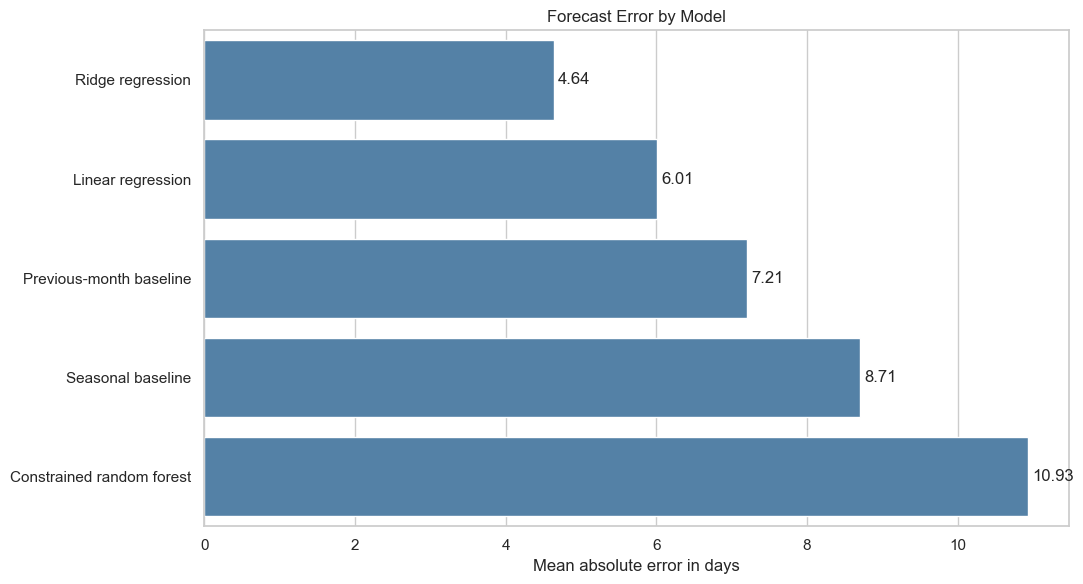

In [51]:
# Model-comparison illustration
plt.figure(figsize=(11, 6))

comparison_order = (
    model_results_df
    .sort_values("MAE")
)

ax = sns.barplot(
    data=comparison_order,
    x="MAE",
    y="Model",
    color="steelblue"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

plt.title("Forecast Error by Model")
plt.xlabel("Mean absolute error in days")
plt.ylabel("")
plt.tight_layout()
plt.show()

#### Test-Period Predictions

The following illustration compares the actual median days on market with the predictions produced by the regression models and the stronger previous-month baseline.  

Ridge regression produced the strongest test-period performance, with an MAE of approximately 4.64 days, an RMSE of 6.02 days, and an R² of 0.820. Its 
predictions differed from the actual median by approximately 4.6 days on average. Ridge regression reduced MAE by 35.7% compared with the stronger 
previous-month baseline.  

Linear regression also outperformed both baselines but was less accurate than Ridge regression. The constrained random forest performed worse than either baseline, indicating that its additional complexity did not improve prediction with the available 121 modeling observations.

In [52]:
# Plot all test-period predictions
prediction_results = pd.DataFrame({
    "target_date": test_data["target_date"],
    "Actual": y_test,
    "Previous-month baseline": test_data["previous_month_baseline"],
    "Seasonal baseline": test_data["seasonal_baseline"],
    "Linear regression": linear_predictions,
    "Ridge regression": ridge_predictions,
    "Constrained random forest": forest_predictions
})

prediction_results.head()

,target_date,Actual,Previous-month baseline,Seasonal baseline,Linear regression,Ridge regression,Constrained random forest
97,2024-09-01,72.0,65.0,57.0,78.337856,73.213953,60.913423
98,2024-10-01,74.0,72.0,63.0,81.273462,76.643313,61.808794
99,2024-11-01,73.0,74.0,66.0,83.467641,77.241142,61.537823
100,2024-12-01,75.0,73.0,74.0,83.960890,79.859523,68.673928
101,2025-01-01,79.0,75.0,75.0,83.887366,78.305330,71.671310


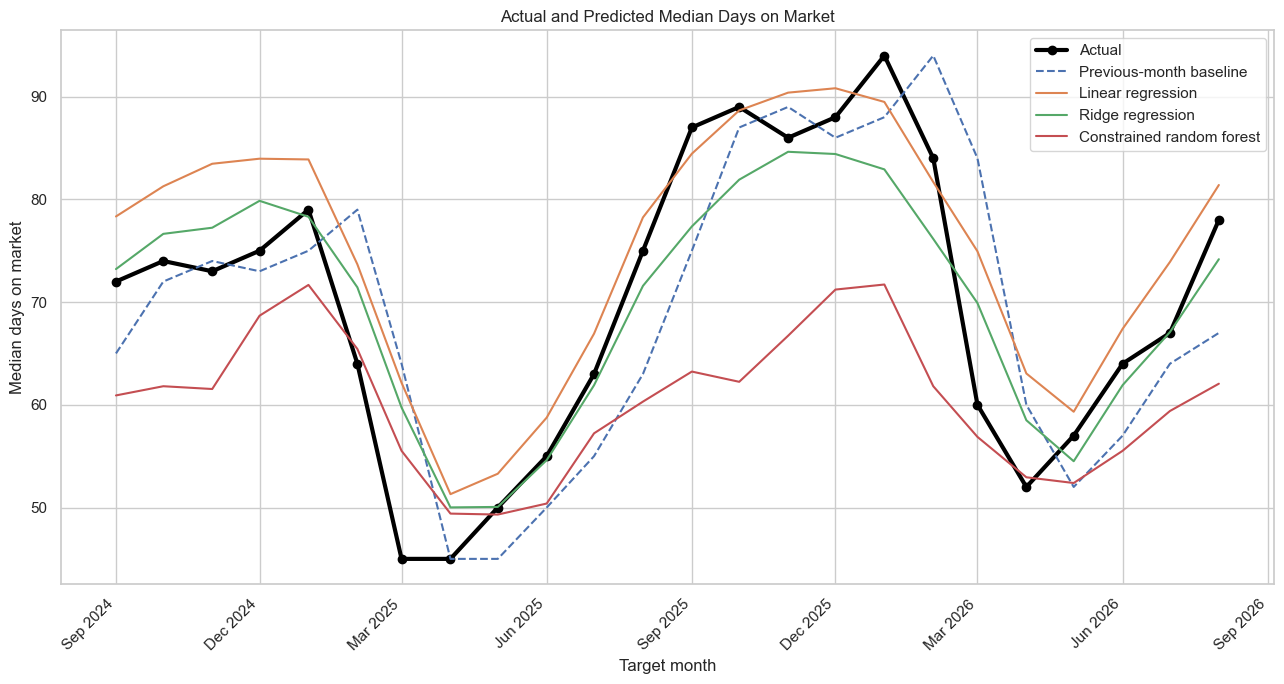

In [53]:
plt.figure(figsize=(13, 7))

plt.plot(
    prediction_results["target_date"],
    prediction_results["Actual"],
    color="black",
    linewidth=3,
    marker="o",
    label="Actual"
)

plt.plot(
    prediction_results["target_date"],
    prediction_results["Previous-month baseline"],
    linestyle="--",
    linewidth=1.5,
    label="Previous-month baseline"
)

plt.plot(
    prediction_results["target_date"],
    prediction_results["Linear regression"],
    linewidth=1.5,
    label="Linear regression"
)

plt.plot(
    prediction_results["target_date"],
    prediction_results["Ridge regression"],
    linewidth=1.5,
    label="Ridge regression"
)

plt.plot(
    prediction_results["target_date"],
    prediction_results["Constrained random forest"],
    linewidth=1.5,
    label="Constrained random forest"
)

plt.title("Actual and Predicted Median Days on Market")
plt.xlabel("Target month")
plt.ylabel("Median days on market")

plt.gca().xaxis.set_major_locator(
    mdates.MonthLocator(interval=3)
)

plt.gca().xaxis.set_major_formatter(
    mdates.DateFormatter("%b %Y")
)

plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

### 11. Ridge Regression Coefficients

The standardized Ridge coefficients show the direction and relative strength of each predictor’s relationship with the following month’s median days on market. Positive coefficients are associated with an increase in the prediction, while negative coefficients are associated with a decrease.

In [54]:
ridge_best_model = ridge_search.best_estimator_

ridge_coefficients = pd.DataFrame({
    "Predictor": feature_columns,
    "Coefficient": ridge_best_model.named_steps["model"].coef_
})

ridge_coefficients["Absolute coefficient"] = (
    ridge_coefficients["Coefficient"].abs()
)

ridge_coefficients = (
    ridge_coefficients
    .sort_values("Absolute coefficient", ascending=False)
    .reset_index(drop=True)
)

ridge_coefficients.round(3)

,Predictor,Coefficient,Absolute coefficient
0,median_days_on_market,5.264,5.264
1,active_listing_count,4.524,4.524
2,new_listing_count,-3.530,3.530
3,month_sin,-3.084,3.084
4,month_cos,2.921,2.921
5,pending_ratio,-2.321,2.321
6,median_listing_price,-1.359,1.359
7,price_reduced_count,1.090,1.090
8,pending_listing_count,0.553,0.553
9,mortgage_rate_30yr_pct,0.158,0.158


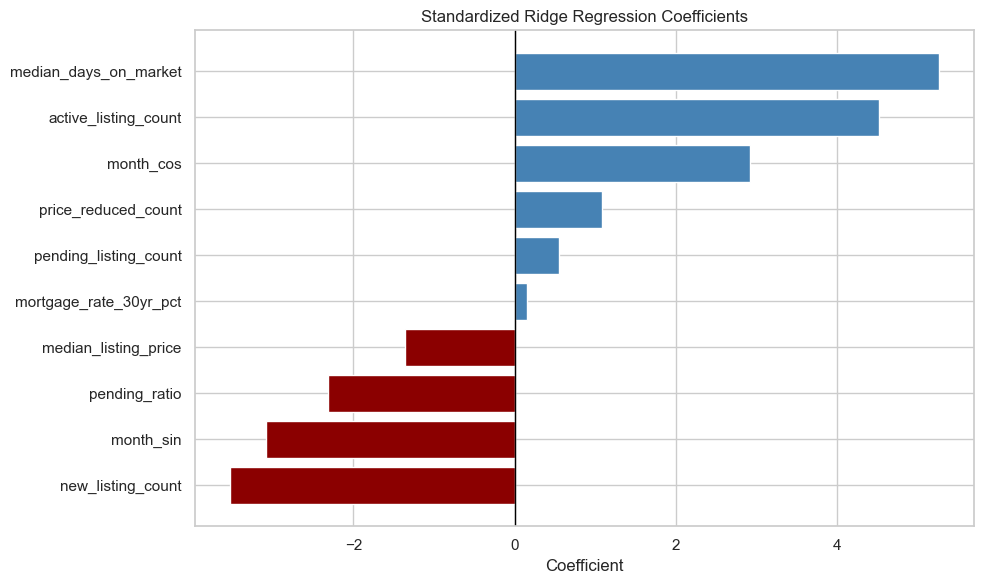

In [55]:
# Coefficient Graph
coefficient_plot = ridge_coefficients.sort_values(
    "Coefficient"
)

plt.figure(figsize=(10, 6))

colors = [
    "darkred" if value < 0 else "steelblue"
    for value in coefficient_plot["Coefficient"]
]

plt.barh(
    coefficient_plot["Predictor"],
    coefficient_plot["Coefficient"],
    color=colors
)

plt.axvline(
    x=0,
    color="black",
    linewidth=1
)

plt.title("Standardized Ridge Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("")
plt.tight_layout()
plt.show()

### 12. Quality-Flag Sensitivity Analysis

The primary model retains all observations because flagged records may represent genuine market changes rather than data errors.  

As a sensitivity test, Ridge regression is trained again after excluding records where either the predictor month or target month was flagged.  

Both versions are evaluated against the same 24-month test period.

In [56]:
# Reduced Training Set
sensitivity_train_data = model_data.loc[
    train_data.index
].copy()

sensitivity_train_data = sensitivity_train_data[
    sensitivity_train_data["quality_flag"].ne(1)
    & sensitivity_train_data["target_quality_flag"].ne(1)
]

X_train_sensitivity = sensitivity_train_data[feature_columns]
y_train_sensitivity = sensitivity_train_data[target_column]

print(
    "Original training observations:",
    len(train_data)
)

print(
    "Sensitivity training observations:",
    len(sensitivity_train_data)
)

Original training observations: 97
Sensitivity training observations: 61


In [57]:
# Train the sensitivity model using the selected Ridge alpha:
ridge_sensitivity_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=selected_alpha))
])

ridge_sensitivity_model.fit(
    X_train_sensitivity,
    y_train_sensitivity
)

ridge_sensitivity_predictions = (
    ridge_sensitivity_model.predict(X_test)
)

ridge_sensitivity_metrics = calculate_metrics(
    y_test,
    ridge_sensitivity_predictions
)

sensitivity_results = pd.DataFrame([
    {
        "Training data": "All training observations",
        **ridge_metrics
    },
    {
        "Training data": "Flagged observations excluded",
        **ridge_sensitivity_metrics
    }
]).round(3)

sensitivity_results

,Training data,MAE,RMSE,R2
0,All training observations,4.637,6.017,0.820
1,Flagged observations excluded,4.876,6.041,0.818


#### Interpretation

Excluding flagged predictor and target observations increased Ridge regression MAE from approximately 4.64 to 4.88 days. RMSE changed only slightly, from approximately 6.02 to 6.04 days, while R² declined from 0.820 to 0.818.  

These small differences indicate that the quality-flagged observations did not materially change the model's overall performance or the conclusion that Ridge regression was the strongest forecasting method.

### 13. Prediction Errors

Residuals represent the difference between the actual and predicted median days on market. Reviewing these errors helps identify months when the selected model substantially overestimated or underestimated market time.


In [58]:
# Examine Ridge residuals
ridge_residuals = y_test.to_numpy() - ridge_predictions

residual_results = pd.DataFrame({
    "Target month": test_data["target_date"].to_numpy(),
    "Actual": y_test.to_numpy(),
    "Predicted": ridge_predictions,
    "Residual": ridge_residuals,
    "Absolute error": np.abs(ridge_residuals)
})

residual_results = residual_results.sort_values(
    "Target month"
)

residual_results.round(2)

,Target month,Actual,Predicted,Residual,Absolute error
0,2024-09-01,72.0,73.21,-1.21,1.21
1,2024-10-01,74.0,76.64,-2.64,2.64
2,2024-11-01,73.0,77.24,-4.24,4.24
3,2024-12-01,75.0,79.86,-4.86,4.86
4,2025-01-01,79.0,78.31,0.69,0.69
5,2025-02-01,64.0,71.44,-7.44,7.44
6,2025-03-01,45.0,59.74,-14.74,14.74
7,2025-04-01,45.0,50.01,-5.01,5.01
8,2025-05-01,50.0,50.06,-0.06,0.06
9,2025-06-01,55.0,54.62,0.38,0.38


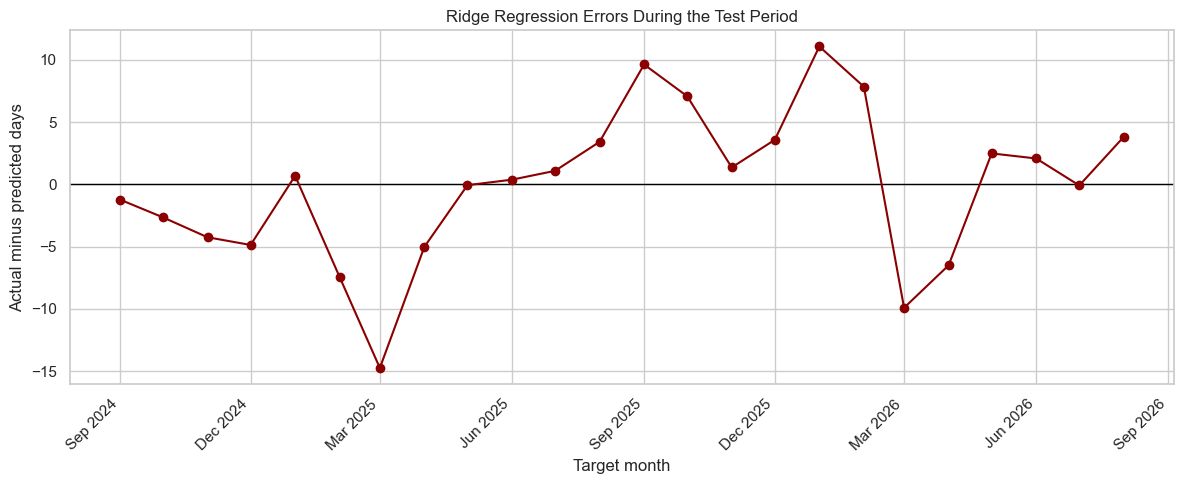

In [59]:
plt.figure(figsize=(12, 5))

plt.axhline(
    y=0,
    color="black",
    linewidth=1
)

plt.plot(
    residual_results["Target month"],
    residual_results["Residual"],
    color="darkred",
    marker="o"
)

plt.title("Ridge Regression Errors During the Test Period")
plt.xlabel("Target month")
plt.ylabel("Actual minus predicted days")

plt.gca().xaxis.set_major_locator(
    mdates.MonthLocator(interval=3)
)

plt.gca().xaxis.set_major_formatter(
    mdates.DateFormatter("%b %Y")
)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 14. September 2026 Forecast

After model evaluation, the selected Ridge model is refitted using all 121 observations with known outcomes.  

The August 2026 housing-market conditions are then used to forecast median days on market for September 2026.  

This future forecast is separate from the test-period results.

In [60]:
# Forecast prediction

final_ridge_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=selected_alpha))
])

# Refit using all observations with known next-month outcomes
final_ridge_model.fit(
    model_data[feature_columns],
    model_data[target_column]
)

# Use the final August 2026 row to forecast September 2026
latest_predictors = modeling_data.iloc[[-1]][feature_columns]

september_2026_forecast = final_ridge_model.predict(
    latest_predictors
)[0]

forecast_month = (
    modeling_data.iloc[-1]["date"]
    + pd.offsets.MonthBegin(1)
)

latest_actual = modeling_data.iloc[-1]["median_days_on_market"]

forecast_change = september_2026_forecast - latest_actual

print("Forecast month:", forecast_month.strftime("%B %Y"))
print("August 2026 actual:", round(latest_actual, 1), "days")
print(
    "September 2026 forecast:",
    round(september_2026_forecast, 1),
    "days"
)
print(
    "Forecast change:",
    round(forecast_change, 1),
    "days"
)

Forecast month: September 2026
August 2026 actual: 78.0 days
September 2026 forecast: 82.5 days
Forecast change: 4.5 days


In [61]:
# Forecast summary table

ridge_improvement = (
    (
        previous_month_metrics["MAE"]
        - ridge_metrics["MAE"]
    )
    / previous_month_metrics["MAE"]
    * 100
)

forecast_summary = pd.DataFrame({
    "Measure": [
        "Forecast month",
        "Predicted median days on market",
        "Most recent actual",
        "Expected monthly change",
        "Test-period MAE",
        "Test-period RMSE",
        "Test-period R²",
        "MAE improvement over baseline"
    ],
    "Result": [
        forecast_month.strftime("%B %Y"),
        f"{september_2026_forecast:.1f} days",
        f"{latest_actual:.0f} days",
        f"{forecast_change:+.1f} days",
        f'{ridge_metrics["MAE"]:.1f} days',
        f'{ridge_metrics["RMSE"]:.1f} days',
        f'{ridge_metrics["R2"]:.3f}',
        f"{ridge_improvement:.1f}%"
    ]
})

forecast_summary

,Measure,Result
0,Forecast month,September 2026
1,Predicted median days on market,82.5 days
2,Most recent actual,78 days
3,Expected monthly change,+4.5 days
4,Test-period MAE,4.6 days
5,Test-period RMSE,6.0 days
6,Test-period R²,0.820
7,MAE improvement over baseline,35.7%


The final model forecasts approximately 82.5 median days on market for September 2026, an increase of about 4.5 days from August. The result suggests a somewhat slower market in which sellers may need to plan for a longer marketing period, while buyers may have more time to consider properties and negotiate. The forecast is an estimate rather than a guarantee. During testing, Ridge regression had an average absolute error of approximately 4.6 days.

### 15. Conclusion

This project examined whether housing-market conditions, mortgage rates, and seasonal patterns could predict Hays County’s median days on market one month in advance. Ridge regression produced the strongest results during the 24-month test period, with an MAE of 4.64 days, an RMSE of 6.02 days, and an R² of 0.820. It reduced MAE by 35.7% compared with the previous-month baseline. Linear regression also outperformed both baselines, while the constrained random forest did not improve prediction accuracy.

After evaluation, the ridge model was trained with all 121 observations having known outcomes. Based on August 2026 conditions, it forecast a median of approximately 82.5 days on market for September 2026. This was about 4.5 days higher than the August value and suggested a somewhat slower market. The forecast should be viewed as a county-level estimate rather than a prediction for an individual property.

### 16. Assumptions and Limitations

#### Assumptions

This analysis assumes that:

* Realtor.com used reasonably consistent definitions and measurement practices throughout the study period.
* Monthly averages of Freddie Mac’s weekly mortgage rates provide a reasonable measure of financing conditions.
* Current-month housing data would be available before the following month’s forecast is produced.
* Relationships found in the historical data remain useful for short-term forecasting.
* Quality-flagged observations may represent actual market changes rather than data errors.

#### Limitations

The dataset contains 122 monthly observations, with 121 available for model development and evaluation. This is a relatively small sample for comparing several forecasting methods. The 24-month test set also represents only one historical period, so performance may differ under other market conditions.

The Realtor.com data represent publicly listed properties and may not include off-market transactions. County-level measures can also hide differences among Kyle, Buda, San Marcos, and rural areas of Hays County. The model does not include property condition, exact location, school district, property type, price range, employment, population growth, or other factors that may affect an individual home. Sudden economic, regulatory, or market changes could also reduce the accuracy of relationships learned from earlier observations.

### 17. Challenges

The original Realtor.com file contained national county-level data and was too large to load unnecessarily in its entirety. This was addressed by importing only the required columns and filtering the records to Hays County. The Freddie Mac observations were reported weekly, while the housing data were monthly, so the weekly rates were averaged by calendar month before the files were joined.

Other challenges included preserving chronological order, preventing future information from entering model training, managing correlated housing measures, and deciding how to treat quality-flagged records. These issues were addressed through one-to-one merge validation, chronological training and testing, time-series cross-validation, ridge regularization, and a separate sensitivity analysis.

### 18. Ethical Assessment

#### Identification

The main concerns are presenting the forecast as a guarantee, relying on county-level data that may not represent every community or transaction, retaining quality-flagged observations, and allowing the results to be used in a way that could disadvantage protected groups.

The Realtor.com data were filtered to Hays County, and the Freddie Mac weekly rates were converted to monthly averages. One invalid mortgage-rate record was removed. The next month’s outcome was shifted onto the current row, and seasonal variables were created. These changes are documented in the notebook.

#### Likelihood and Impact

Misinterpreting the forecast as a guarantee is reasonably likely if uncertainty is not explained and could have a high financial impact. Incomplete geographic representation is likely because county-level data do not describe every neighborhood, although its impact is moderate when the forecast is used only as a general indicator. Misleading results from quality-flagged records have a moderate likelihood and impact. Misuse involving protected groups is less likely, but its impact could be serious.

#### Mitigation

The forecast should be labeled as an estimate and presented with its historical error. County-level and source limitations should be disclosed, and unusual monthly changes should be reviewed before release. The sensitivity analysis documents the effect of retaining flagged observations.

Protected characteristics were excluded from the model. The results must not be used to target or exclude protected groups and should be applied consistently with the Fair Housing Act. The data were obtained from public Realtor.com and Freddie Mac sources and do not contain personal or individual-level information.

### 19. Recommendations

Real estate professionals should use the forecast as an early indicator of county-level market speed and not as a guarantee of how long a particular property will remain on the market. The estimate should be considered along with comparable sales, property condition, location, list price, available inventory, and current professional knowledge.

Each forecast should include the most recent actual value and the model’s historical error so clients can understand the uncertainty involved. Unusually large month-to-month changes should be reviewed before the forecast is shared. Model performance should also be compared regularly with the previous-month and seasonal baselines to confirm that the ridge model continues to provide additional value.

Future analysis could add city-level data, separate models by property type or price range, and include employment, building permits, sales activity, and population measures. Prediction intervals and additional rolling historical tests would provide a clearer view of forecast uncertainty and performance over time.

### 20. Implementation Plan

The forecasting process can be updated each month after new Realtor.com and Freddie Mac data become available.

1. Download the latest source files.
2. Run the data-preparation and validation cells.
3. Confirm that no months are missing or duplicated and review missing values and quality flags.
4. Recalculate the monthly mortgage-rate averages and merge the two data sources.
5. Create the next-month target, seasonal measures, and baseline forecasts.
6. Refit the ridge model using all observations with known outcomes.
7. Generate the following month’s forecast.
8. Compare recent errors with the model’s earlier test performance.
9. Have an analyst or broker review unusual results before release.

A future CRM dashboard could display the next-month forecast, the latest actual value, the expected change, historical error, and a brief explanation for clients. The model should be reevaluated periodically and retrained whenever new observations are added. If performance begins to decline or the model no longer outperforms the baselines, its predictors and settings should be reviewed.

### 21. Future Uses and Additional Applications

Future versions could include city-level data for Kyle, Buda, and San Marcos or develop separate forecasts by property type and price range. Employment, building-permit, sales, and population data could provide additional information about local demand. Future analysis could also calculate prediction intervals and use rolling historical test periods to determine whether model performance remains consistent over time.


### 22. GitHub and Reproducibility

**GitHub repository:** [Hays County Real Estate Analysis](https://github.com/ferrillt/Hays-County-Real-Estate-Analysis)

The two original source files are not stored in the repository. They must be downloaded from their publishers and placed in the project’s `data` folder.

| Source | Download location | Required local filename |
|---|---|---|
| Freddie Mac historical weekly mortgage rates | [Freddie Mac Primary Mortgage Market Survey](https://www.freddiemac.com/pmms) | `FreddieMac_1971-2026_historicalweeklydata.csv` |
| Realtor.com county housing inventory history | [Realtor.com Residential Real Estate Data Library](https://www.realtor.com/research/data/) | `RDC_Inventory_Core_Metrics_County_History.csv` |

The notebook creates the remaining datasets in the following order:

1. The Freddie Mac preparation section converts weekly mortgage rates into monthly averages and creates `freddie_mac_monthly.csv`.
2. The Realtor.com preparation section filters the national county file to Hays County, Texas, using FIPS code `48209`, and creates `realtor_hays_county.csv`.
3. Download the original Realtor.com county-history file and Freddie Mac weekly mortgage-rate file using the instructions in the repository README.

The original files should be placed in the `data` folder before the notebook is run. The notebook should then be executed in order from the first cell through the final cell. The project repository contains the Jupyter notebook, prepared Hays County data files, a requirements file, project documentation, and instructions for obtaining the original Realtor.com and Freddie Mac datasets.

The original files are excluded from GitHub because the national Realtor.com file exceeds GitHub’s normal file-size limit. The three smaller prepared datasets are included so the analysis can be reviewed without downloading the original national file.